In [ ]:
!pip install pandas openpyxl rapidfuzz langchain-text-splitters sentence-transformers pytrec_eval numpy

In [ ]:
# @title
import google.colab
print(google.colab.__version__)

0.0.1a2


In [ ]:
# @title
import platform
print(platform.python_version())

3.12.13


In [ ]:
# @title
import os
import shutil

# Eliminar todos los archivos del directorio actual (excepto subdirectorios)
for file in os.listdir('.'):
    if os.path.isfile(file):
        os.remove(file)

In [ ]:
# Importar  data
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving Data.xlsx to Data.xlsx


In [ ]:
# llegir les dades
corpus_df = pd.read_excel("Data.xlsx", sheet_name="Corpus")
qa_df = pd.read_excel("Data.xlsx", sheet_name="QA")

print("\n--- Corpus ---")
print(f"Columnas: {corpus_df.columns.tolist()}")
print(f"Filas: {len(corpus_df)}")
display(corpus_df.head(5))

print("\n--- QA ---")
print(f"Columnas: {qa_df.columns.tolist()}")
print(f"Filas: {len(qa_df)}")
display(qa_df.head(5))


--- Corpus ---
Columnas: ['ID', 'Title', 'Text']
Filas: 11


,ID,Title,Text
0,DOC_001,Regulations for External Academic Internships,The statistics degree is from the University o...
1,DOC_002,Processing of external academic internships,GIPE is the application through which internsh...
2,DOC_003,Bachelor’s Thesis,MODALITY OF Bachelor’s Thesis. There are four ...
3,DOC_004,International exchange program,Requirements for UB students on international ...
4,DOC_005,General regulations of UB,Information on the Grading Process: Grades for...



--- QA ---
Columnas: ['ID', 'Q', 'SA', 'LA', 'Source_doc', 'Source_text']
Filas: 136


,ID,Q,SA,LA,Source_doc,Source_text
0,Q_001,What percentage of credits must an undergradua...,50 % of credits.,The student must have passed at least 50% of t...,DOC_001,In the case of curricular internships: d) Clas...
1,Q_002,Can class schedules overlap with curricular in...,No.,"No, class schedules and practicum schedules ca...",DOC_001,In the case of curricular internships: d) Clas...
2,Q_003,What is the minimum number of hours required f...,300 hours.,The minimum duration of a curricular internshi...,DOC_001,Degree: Curricular internships: you may undert...
3,Q_004,What is the maximum number of hours required f...,375 hours.,The maximum duration of a curricular internshi...,DOC_001,Curricular internships: you may undertake as m...
4,Q_005,In which period should a student complete thei...,Internships must be completed within the acade...,Internships must be completed within the acade...,DOC_001,"Internships, both curricular and extracurricul..."


=== Longitud de Source_text (caracters) ===
count    136.000000
mean     180.764706
std       80.019834
min       46.000000
25%      116.750000
50%      168.500000
75%      230.000000
90%      315.500000
95%      326.500000
99%      369.550000
max      424.000000
Name: longitud_ref, dtype: float64


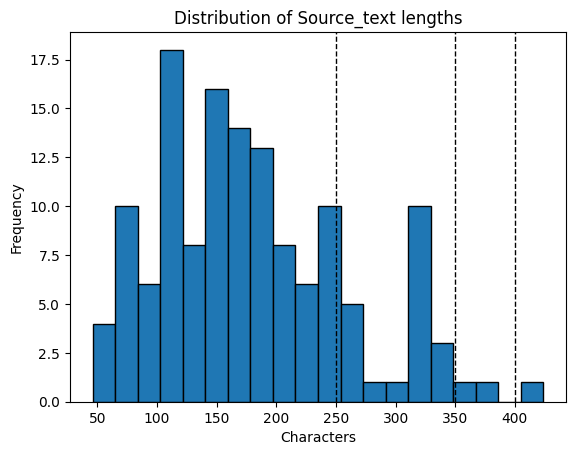

In [ ]:
# Calcular longitud (nº de caràcters) de cada text de referencia(Source_text)
qa_df['longitud_ref'] = qa_df['Source_text'].astype(str).apply(len)

# Estadístiques descriptives
print("=== Longitud de Source_text (caracters) ===")
print(qa_df['longitud_ref'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

# Visualización
import matplotlib.pyplot as plt
plt.hist(qa_df['longitud_ref'], bins=20, edgecolor='black')
plt.title('Distribution of Source_text lengths')
plt.xlabel('Characters')
plt.ylabel('Frequency')

plt.axvline(x=250, linestyle='--', color='black', linewidth=1)
plt.axvline(x=350, linestyle='--', color='black', linewidth=1)
plt.axvline(x=400, linestyle='--', color='black', linewidth=1)



plt.show()

In [ ]:
# Divisió del document en chunks més petits.
import langchain_text_splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Paràmetres del chunk
# s'ha provat varies combinacions de chunk size, chunk overlap per obtenir millor resultats de recuperació
CHUNK_SIZE = 450
CHUNK_OVERLAP = 100

# Configurar el splitter para respectar paràgrafs.
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""],   # prioritzar els salts de linia
    length_function=len,
)

chunks_list = []

# Iterar sobre cada doc del corpus
for idx, row in corpus_df.iterrows():
    doc_id = row['ID']
    title = row['Title']
    text = row['Text']

    # paste del titol amb el text
    full_text = f"{title}\n\n{text}" if pd.notna(title) else text

    # Dividir en chunks
    doc_chunks = text_splitter.split_text(full_text)

    # Guardar cada chunk
    for i, chunk_text in enumerate(doc_chunks):
        chunks_list.append({
            'doc_id': doc_id,
            'chunk_id': f"{doc_id}_chunk_{i:04d}",
            'posicio': i,
            'text_chunk': chunk_text
        })

# Crear DataFrame de chunks
chunks_df = pd.DataFrame(chunks_list)


In [ ]:
# Mostrar resumen de los chunks
print(f"Total de documentos procesados: {corpus_df['ID'].nunique()}")
print(f"Total de chunks generados: {len(chunks_df)}")
print(f"Promedio de chunks por documento: {len(chunks_df) / corpus_df['ID'].nunique():.1f}")
print(f"Longitud media de chunk: {chunks_df['text_chunk'].str.len().mean():.0f} caracteres")
print(f"Longitud mínima / máxima: {chunks_df['text_chunk'].str.len().min()} / {chunks_df['text_chunk'].str.len().max()}")

# Mostrar primeras filas
chunks_df.head(5)

Total de documentos procesados: 11
Total de chunks generados: 114
Promedio de chunks por documento: 10.4
Longitud media de chunk: 265 caracteres
Longitud mínima / máxima: 16 / 449


,doc_id,chunk_id,posicio,text_chunk
0,DOC_001,DOC_001_chunk_0000,0,Regulations for External Academic Internships
1,DOC_001,DOC_001_chunk_0001,1,The statistics degree is from the University o...
2,DOC_001,DOC_001_chunk_0002,2,. The program has a total of 240 credits. Requ...
3,DOC_001,DOC_001_chunk_0003,3,". e) At the time the intership begins, the und..."
4,DOC_001,DOC_001_chunk_0004,4,Duration and Schedules of Internships The ext...
5,DOC_001,DOC_001_chunk_0005,5,. Each training project must include a minimum...
6,DOC_001,DOC_001_chunk_0006,6,"Internships, both curricular and extracurricul..."
7,DOC_001,DOC_001_chunk_0007,7,"Internships, both curricular and extracurricul..."
8,DOC_001,DOC_001_chunk_0008,8,. The student may work a maximum of 6 hours pe...
9,DOC_001,DOC_001_chunk_0009,9,Economic Aspects: Each training project requir...


In [ ]:
# funció per normalizar el text, preprocessing abans de mapeig
import re
from rapidfuzz import fuzz

def normalizar_texto(texto: str) -> str:
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = re.sub(r'\s+', ' ', texto)            # espais múltiples a un
    texto = re.sub(r'[^\w\s]', '', texto)         # eliminae puntuació
    return texto.strip()

In [ ]:
# funció mapeig dels chunks amb source_text amb un thershold
def encontrar_chunk_relevante(source_doc, source_text, chunks_df, umbral):
    # 1. Filtrar chunks del document
    chunks_doc = chunks_df[chunks_df['doc_id'] == source_doc].copy()
    if chunks_doc.empty:
        return None, 0.0, "Document no trobat"

    # 2. Normalizar referencia
    ref_norm = normalizar_texto(source_text)

    # 3. Calcular similitud con cada chunk y quedarse con el máximo
    best_chunk = None
    best_sim = 0.0

    for _, row in chunks_doc.iterrows():
        sim = fuzz.partial_ratio(ref_norm, row['text_chunk_norm']) / 100.0
        if sim > best_sim:
            best_sim = sim
            best_chunk = row['chunk_id']

    # 4. Evaluar contra el umbral
    if best_sim >= umbral:
        return best_chunk, best_sim, "OK"
    else:
        return None, best_sim, f"Similitud baja ({best_sim:.2f} < {umbral})"

In [ ]:
# Pre-normalizar los chunks
chunks_df['text_chunk_norm'] = chunks_df['text_chunk'].apply(normalizar_texto)

# Aplicar la función a cada fila del dataset QA
resultados = []
for idx, row in qa_df.iterrows():
    chunk_id, sim, estado = encontrar_chunk_relevante(
        row['Source_doc'],
        row['Source_text'],
        chunks_df,
        umbral=0.75
    )
    resultados.append((chunk_id, sim, estado))

# Añadir columnas al DataFrame
qa_df['chunk_relevante'] = [r[0] for r in resultados]
qa_df['similitud_max'] = [r[1] for r in resultados]
qa_df['estado_mapeo'] = [r[2] for r in resultados]

# Mostrar resumen
print("--- Resumen del mapeo ---")
print(qa_df['estado_mapeo'].value_counts())
print(f"\nSimilitud media en casos OK: {qa_df[qa_df['estado_mapeo'] == 'OK']['similitud_max'].mean():.3f}")
# Mostrar
qa_df[['ID', 'Q', 'Source_doc', 'chunk_relevante', 'similitud_max', 'estado_mapeo']].head(10)

--- Resumen del mapeo ---
estado_mapeo
OK    136
Name: count, dtype: int64

Similitud media en casos OK: 0.999


,ID,Q,Source_doc,chunk_relevante,similitud_max,estado_mapeo
0,Q_001,What percentage of credits must an undergradua...,DOC_001,DOC_001_chunk_0003,0.936937,OK
1,Q_002,Can class schedules overlap with curricular in...,DOC_001,DOC_001_chunk_0003,0.936937,OK
2,Q_003,What is the minimum number of hours required f...,DOC_001,DOC_001_chunk_0005,1.000000,OK
3,Q_004,What is the maximum number of hours required f...,DOC_001,DOC_001_chunk_0005,1.000000,OK
4,Q_005,In which period should a student complete thei...,DOC_001,DOC_001_chunk_0006,1.000000,OK
5,Q_006,On which days can internships be carried out?,DOC_001,DOC_001_chunk_0007,1.000000,OK
6,Q_007,Between what hours can internships take place?,DOC_001,DOC_001_chunk_0007,1.000000,OK
7,Q_008,What is the maximum number of hours a student ...,DOC_001,DOC_001_chunk_0007,1.000000,OK
8,Q_009,Are there any exceptions to the daily working ...,DOC_001,DOC_001_chunk_0008,1.000000,OK
9,Q_010,Who must make a financial contribution for eac...,DOC_001,DOC_001_chunk_0009,1.000000,OK


In [ ]:
# Filtrar filas donde el mapeo no fue OK
no_ok = qa_df[qa_df['estado_mapeo'] != 'OK'].copy()

# Mostrar cuántas hay
print(f"Filas con problema: {len(no_ok)}")

# Mostrar las columnas relevantes
display(no_ok[['ID', 'Q', 'Source_doc', 'chunk_relevante', 'similitud_max', 'estado_mapeo']])

Filas con problema: 0


,ID,Q,Source_doc,chunk_relevante,similitud_max,estado_mapeo


In [ ]:
qa_df = qa_df.drop("estado_mapeo",axis=1)

In [ ]:
# funció de recuperació de chunks i calul de metriques
# en tot el corpus
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

def evaluar_modelo_completo(modelo_nombre, qa_df, chunks_df, k_vals=[1, 3, 5],
                            tipo_modelo='default', max_mrr_rank=3):

    modelo = SentenceTransformer(modelo_nombre)

    # Preparar textos según el tipo de modelo
    if tipo_modelo == 'e5':
        preguntas = ["query: " + q for q in qa_df['Q']]
        chunks_textos = ["passage: " + c for c in chunks_df['text_chunk']]
    elif tipo_modelo == 'qwen':
        instruccion = "Given a web search query, retrieve relevant passages that answer the query"
        preguntas = [f"Instruct: {instruccion}\nQuery: {q}" for q in qa_df['Q']]
        # Para los chunks, el modelo Qwen también recomienda añadir "Passage: "
        chunks_textos = ["Passage: " + c for c in chunks_df['text_chunk']]
    else:  # default
        preguntas = qa_df['Q'].tolist()
        chunks_textos = chunks_df['text_chunk'].tolist()

    # Generar embeddings
    preguntas_emb = modelo.encode(preguntas, show_progress_bar=False)
    chunks_emb = modelo.encode(chunks_textos, show_progress_bar=False)

    hits = {k: 0 for k in k_vals}
    reciprocal_ranks = []
    ranks_list = []
    all_chunk_ids = chunks_df['chunk_id'].tolist()

    for i, (_, row) in enumerate(qa_df.iterrows()):
        chunk_relevante = row['chunk_relevante']
        sims = cosine_similarity([preguntas_emb[i]], chunks_emb)[0]
        orden = np.argsort(sims)[::-1]
        chunks_ordenados = [all_chunk_ids[j] for j in orden]

        try:
            rank = chunks_ordenados.index(chunk_relevante) + 1
        except ValueError:
            rank = np.inf

        ranks_list.append(rank)

        for k in k_vals:
            if rank <= k:
                hits[k] += 1

        if rank != np.inf and rank <= max_mrr_rank:
            reciprocal_ranks.append(1.0 / rank)
        else:
            reciprocal_ranks.append(0.0)

    total = len(qa_df)
    metricas = {f'HR@{k}': hits[k] / total for k in k_vals}
    metricas['MRR'] = np.mean(reciprocal_ranks) if reciprocal_ranks else 0.0
    metricas['modelo'] = modelo_nombre
    return metricas, ranks_list

In [ ]:
modelos_info = [
    ('sentence-transformers/all-MiniLM-L6-v2', 'default'),
    ('sentence-transformers/all-MiniLM-L12-v2', 'default'),
    ('BAAI/bge-base-en-v1.5', 'default'),
    ('BAAI/bge-small-en-v1.5', 'default'),
    ('intfloat/multilingual-e5-large', 'e5'),
    ('Alibaba-NLP/gte-Qwen2-1.5B-instruct', 'qwen')
]

tabla_metricas = []
dict_ranks = {}

for nombre, tipo in modelos_info:
    print(f"Evaluando {nombre} (tipo: {tipo})...")
    met, ranks = evaluar_modelo_completo(nombre, qa_df, chunks_df,
                                         k_vals=[1,3,5],
                                         tipo_modelo=tipo,
                                         max_mrr_rank=3)
    tabla_metricas.append(met)
    dict_ranks[nombre] = ranks

In [ ]:
df_ranks = pd.DataFrame(dict_ranks)
met_df = pd.DataFrame(tabla_metricas)
met_df

,HR@1,HR@3,HR@5,MRR,modelo
0,0.595588,0.801471,0.845588,0.688725,sentence-transformers/all-MiniLM-L6-v2
1,0.580882,0.838235,0.904412,0.699755,sentence-transformers/all-MiniLM-L12-v2
2,0.647059,0.882353,0.941176,0.756127,BAAI/bge-base-en-v1.5
3,0.639706,0.867647,0.904412,0.740196,BAAI/bge-small-en-v1.5
4,0.691176,0.911765,0.948529,0.790441,intfloat/multilingual-e5-large
5,0.470588,0.536765,0.544118,0.502451,Alibaba-NLP/gte-Qwen2-1.5B-instruct


In [ ]:
# @title
df_ranks.to_csv("df_ranks_350-150.csv")
files.download("df_ranks_350-150.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

# 1. Cargar modelo
modelo_nombre = "intfloat/multilingual-e5-large"
modelo = SentenceTransformer(modelo_nombre)

# 2. Lista de textos
textos = ["woman","man","queen","king"]

# 3. Generar embeddings
embeddings = modelo.encode(textos, show_progress_bar=False)

# 4. Reducción a 2D con PCA
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


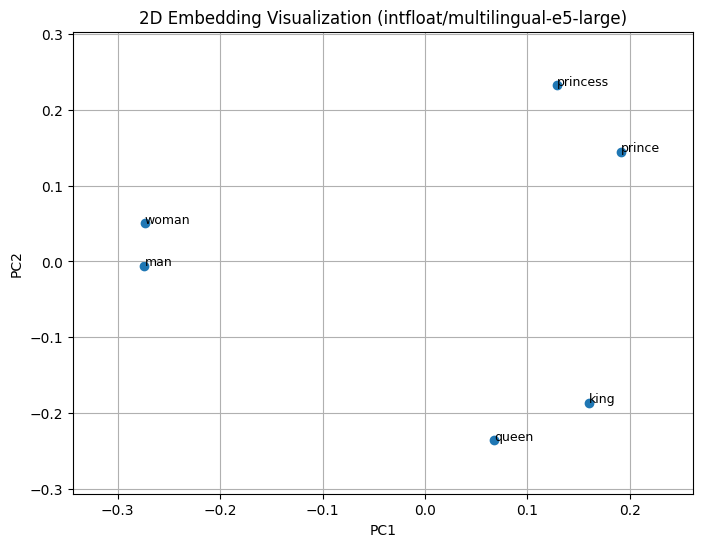

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 5. Graficar con límites ampliados
plt.figure(figsize=(8, 6))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1])

for i, txt in enumerate(textos):
    plt.annotate(txt, (emb_2d[i, 0], emb_2d[i, 1]), fontsize=9)

# Ampliar límites (margen del 15%)
x_min, x_max = emb_2d[:, 0].min(), emb_2d[:, 0].max()
y_min, y_max = emb_2d[:, 1].min(), emb_2d[:, 1].max()

margin_x = (x_max - x_min) * 0.15
margin_y = (y_max - y_min) * 0.15

plt.xlim(x_min - margin_x, x_max + margin_x)
plt.ylim(y_min - margin_y, y_max + margin_y)

plt.title(f"2D Embedding Visualization ({modelo_nombre})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.savefig('embeddings_2d.png', dpi=150, bbox_inches='tight')
plt.show()

# Descargar en Colab
from google.colab import files
files.download('embeddings_2d.png')

In [ ]:
# Importar  data
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving df_ranks_450-100.csv to df_ranks_450-100.csv


In [ ]:
df_ranks = pd.read_csv("df_ranks_450-100.csv", index_col=0)
df_ranks.head()

,sentence-transformers/all-MiniLM-L6-v2,sentence-transformers/all-MiniLM-L12-v2,BAAI/bge-base-en-v1.5,BAAI/bge-small-en-v1.5,intfloat/multilingual-e5-large,Alibaba-NLP/gte-Qwen2-1.5B-instruct
0,1,1,1,1,1,1
1,6,10,22,13,13,3
2,3,1,2,4,2,1
3,4,1,3,3,2,1
4,2,1,1,1,1,1


In [ ]:
# @title
# Descargar los DataFrames como CSV
chunks_df.to_csv("chunks_df.csv", index=False)
qa_df.to_csv("qa_df.csv", index=False)
from google.colab import files
files.download("chunks_df.csv")
files.download("qa_df.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>